# EDA: SemEval 2026 Task 13 — Human vs AI-Generated Code Classification

Binary classification of code snippets as **human-written (label 0)** or **AI-generated (label 1)**.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Consistent colors for labels
LABEL_COLORS = {0: '#4C72B0', 1: '#DD8452'}  # blue=human, orange=AI
LABEL_NAMES = {0: 'Human', 1: 'AI-generated'}

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load all datasets
DATA_DIR = 'Task_A'

train = pd.read_parquet(f'{DATA_DIR}/train.parquet')
val = pd.read_parquet(f'{DATA_DIR}/validation.parquet')
test_sample = pd.read_parquet(f'{DATA_DIR}/test_sample.parquet')
test = pd.read_parquet(f'{DATA_DIR}/test.parquet')

print("=== Dataset Shapes ===")
print(f"Train:       {train.shape}")
print(f"Validation:  {val.shape}")
print(f"Test Sample: {test_sample.shape}")
print(f"Test:        {test.shape}")

print("\n=== Train Columns ===")
print(train.columns.tolist())
print("\n=== Test Columns ===")
print(test.columns.tolist())

print("\n=== Train Info ===")
display(train.dtypes)
print(f"\nMissing values in train: {train.isnull().sum().sum()}")
print(f"Missing values in test:  {test.isnull().sum().sum()}")

print("\n=== Train Head ===")
display(train.head(3))

=== Dataset Shapes ===
Train:       (500000, 4)
Validation:  (100000, 4)
Test Sample: (1000, 4)
Test:        (500000, 2)

=== Train Columns ===
['code', 'generator', 'label', 'language']

=== Test Columns ===
['ID', 'code']

=== Train Info ===


code           str
generator      str
label        int64
language       str
dtype: object


Missing values in train: 0
Missing values in test:  0

=== Train Head ===


,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python


## 2. Label Distribution

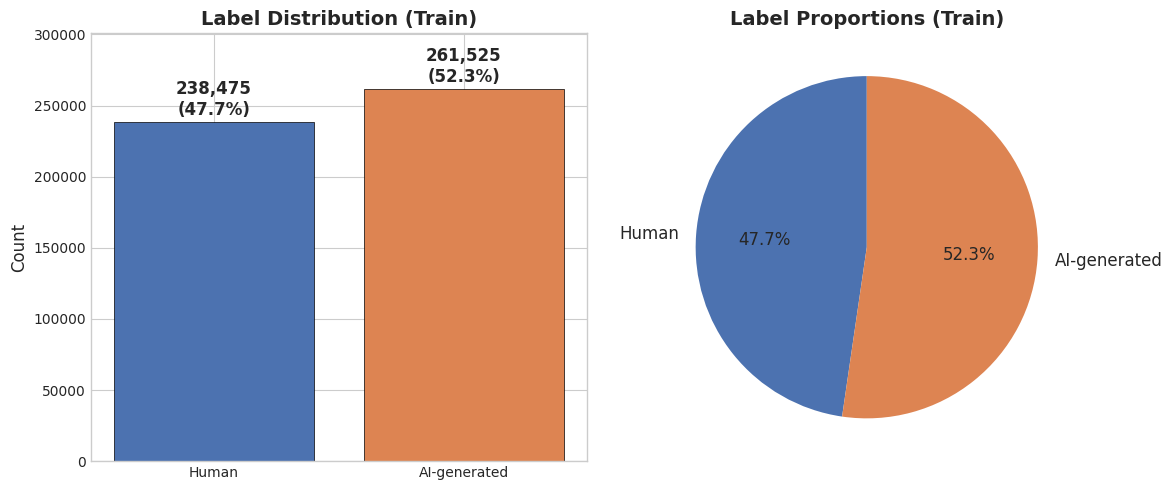

Train label distribution:
label
1    261525
0    238475

Validation label distribution:
label
1    52305
0    47695


In [3]:
# Label distribution in training set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
label_counts = train['label'].value_counts().sort_index()
bars = axes[0].bar(
    [LABEL_NAMES[i] for i in label_counts.index],
    label_counts.values,
    color=[LABEL_COLORS[i] for i in label_counts.index],
    edgecolor='black', linewidth=0.5
)
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2000,
                 f'{count:,}\n({count/len(train)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Label Distribution (Train)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim(0, label_counts.max() * 1.15)

# Pie chart
axes[1].pie(label_counts.values,
            labels=[LABEL_NAMES[i] for i in label_counts.index],
            colors=[LABEL_COLORS[i] for i in label_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Label Proportions (Train)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Train label distribution:\n{train['label'].value_counts().to_string()}")
print(f"\nValidation label distribution:\n{val['label'].value_counts().to_string()}")

## 3. Language Distribution

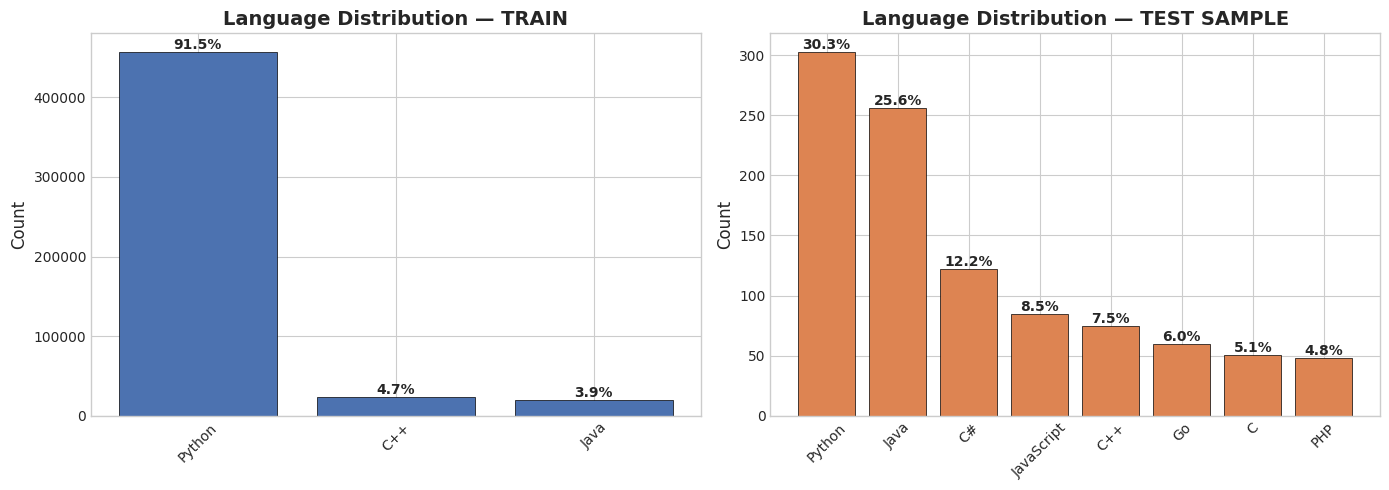

Languages in TRAIN: ['C++', 'Java', 'Python']
Languages in TEST SAMPLE: ['C', 'C#', 'C++', 'Go', 'Java', 'JavaScript', 'PHP', 'Python']

*** UNSEEN languages in test: ['C', 'C#', 'Go', 'JavaScript', 'PHP'] ***
This is a major domain shift challenge!


In [4]:
# Language distribution: train vs test_sample (domain shift!)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train languages
train_lang = train['language'].value_counts()
bars1 = axes[0].bar(train_lang.index, train_lang.values, color='#4C72B0', edgecolor='black', linewidth=0.5)
for bar, count in zip(bars1, train_lang.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{count/len(train)*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Language Distribution — TRAIN', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Test sample languages
test_lang = test_sample['language'].value_counts()
bars2 = axes[1].bar(test_lang.index, test_lang.values, color='#DD8452', edgecolor='black', linewidth=0.5)
for bar, count in zip(bars2, test_lang.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{count/len(test_sample)*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Language Distribution — TEST SAMPLE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Highlight the domain shift
train_langs = set(train['language'].unique())
test_langs = set(test_sample['language'].unique())
unseen = test_langs - train_langs
print(f"Languages in TRAIN: {sorted(train_langs)}")
print(f"Languages in TEST SAMPLE: {sorted(test_langs)}")
print(f"\n*** UNSEEN languages in test: {sorted(unseen)} ***")
print("This is a major domain shift challenge!")

## 4. Generator Analysis

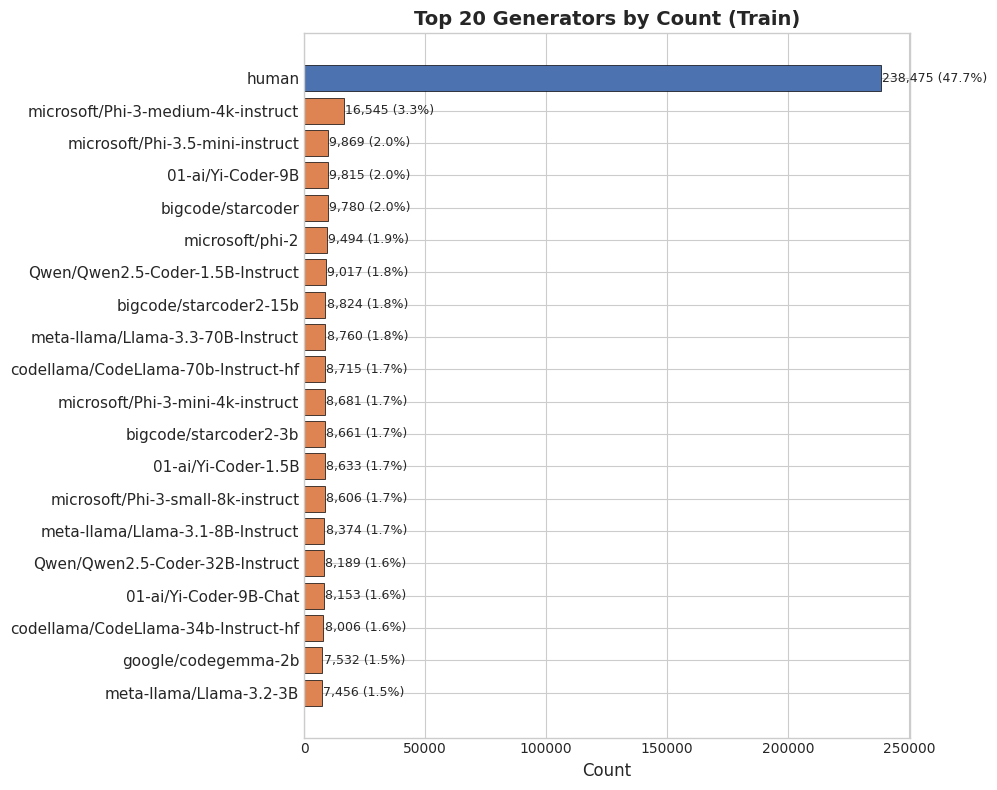

Total unique generators: 35

All generators:
generator
human                                       238475
microsoft/Phi-3-medium-4k-instruct           16545
microsoft/Phi-3.5-mini-instruct               9869
01-ai/Yi-Coder-9B                             9815
bigcode/starcoder                             9780
microsoft/phi-2                               9494
Qwen/Qwen2.5-Coder-1.5B-Instruct              9017
bigcode/starcoder2-15b                        8824
meta-llama/Llama-3.3-70B-Instruct             8760
codellama/CodeLlama-70b-Instruct-hf           8715
microsoft/Phi-3-mini-4k-instruct              8681
bigcode/starcoder2-3b                         8661
01-ai/Yi-Coder-1.5B                           8633
microsoft/Phi-3-small-8k-instruct             8606
meta-llama/Llama-3.1-8B-Instruct              8374
Qwen/Qwen2.5-Coder-32B-Instruct               8189
01-ai/Yi-Coder-9B-Chat                        8153
codellama/CodeLlama-34b-Instruct-hf           8006
google/codegemma-2b        

In [5]:
# Generator distribution — top 20
gen_counts = train['generator'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#4C72B0' if g == 'human' else '#DD8452' for g in gen_counts.index]
bars = ax.barh(range(len(gen_counts)), gen_counts.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(gen_counts)))
ax.set_yticklabels(gen_counts.index, fontsize=11)
ax.invert_yaxis()

# Add count labels
for i, (bar, count) in enumerate(zip(bars, gen_counts.values)):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2.,
            f'{count:,} ({count/len(train)*100:.1f}%)',
            ha='left', va='center', fontsize=9)

ax.set_title('Top 20 Generators by Count (Train)', fontsize=14, fontweight='bold')
ax.set_xlabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total unique generators: {train['generator'].nunique()}")
print(f"\nAll generators:\n{train['generator'].value_counts().to_string()}")

## 5. Code Length Analysis

=== Code Length Statistics ===

Human:
  Mean:   600
  Median: 319
  Std:    1722
  Min:    0
  Max:    475,006

AI-generated:
  Mean:   1053
  Median: 726
  Std:    894
  Min:    1
  Max:    11,964


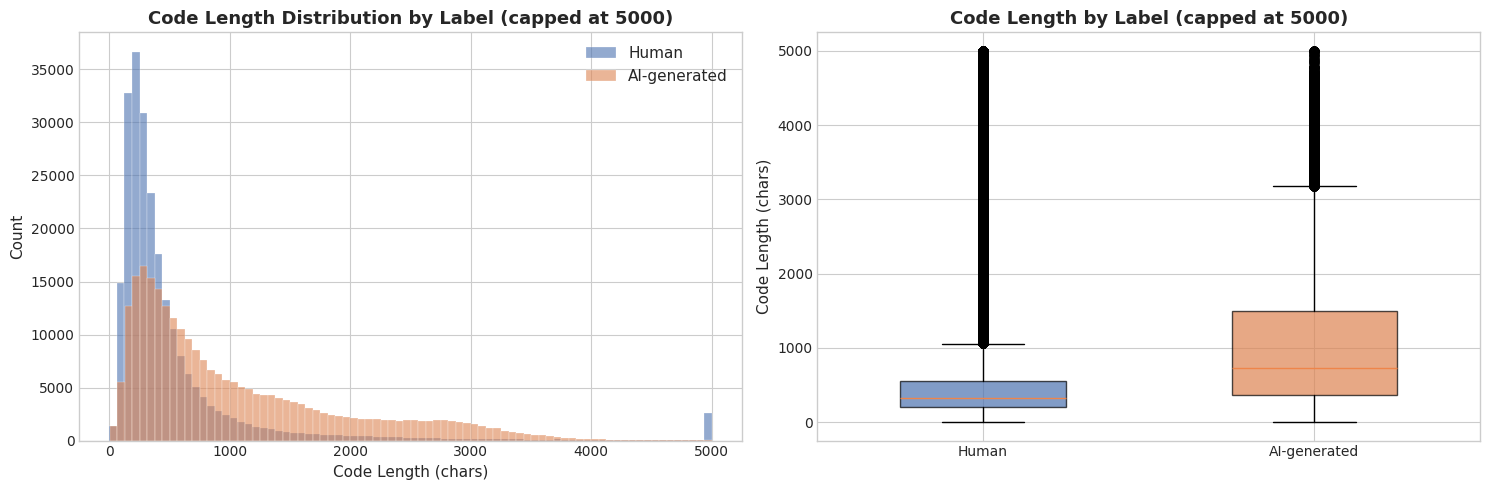

In [6]:
# Code length analysis
train['code_len'] = train['code'].str.len()

# Print summary stats by label
print("=== Code Length Statistics ===")
for label in [0, 1]:
    subset = train[train['label'] == label]['code_len']
    print(f"\n{LABEL_NAMES[label]}:")
    print(f"  Mean:   {subset.mean():.0f}")
    print(f"  Median: {subset.median():.0f}")
    print(f"  Std:    {subset.std():.0f}")
    print(f"  Min:    {subset.min()}")
    print(f"  Max:    {subset.max():,}")

# Cap at 5000 for visualization
cap = 5000
train['code_len_capped'] = train['code_len'].clip(upper=cap)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overlapping histogram
for label in [0, 1]:
    subset = train[train['label'] == label]['code_len_capped']
    axes[0].hist(subset, bins=80, alpha=0.6, label=LABEL_NAMES[label],
                 color=LABEL_COLORS[label], edgecolor='white', linewidth=0.3)
axes[0].set_title('Code Length Distribution by Label (capped at 5000)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Code Length (chars)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=11)

# Box plot
data_for_box = [train[train['label'] == 0]['code_len_capped'],
                train[train['label'] == 1]['code_len_capped']]
bp = axes[1].boxplot(data_for_box, labels=['Human', 'AI-generated'],
                     patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [LABEL_COLORS[0], LABEL_COLORS[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Code Length by Label (capped at 5000)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Code Length (chars)', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Code Characteristics by Label

,Avg Line Count,Avg Line Length,Comment Ratio,Whitespace Ratio,Has Docstring (%)
Human,32.786,20.040,0.005,0.268,0.620
AI-generated,40.258,27.264,0.062,0.298,18.017


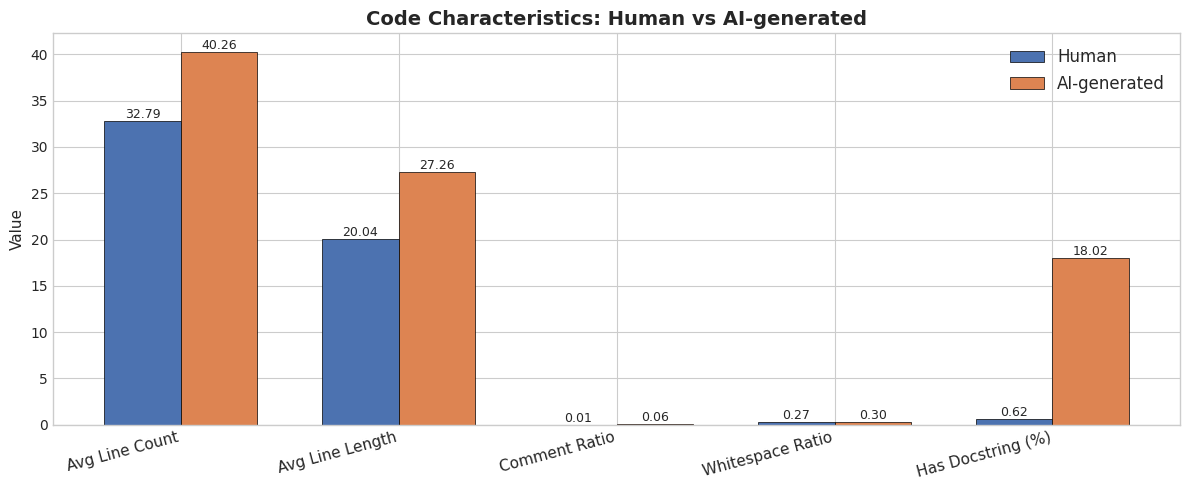

In [7]:
# Compute code characteristics on a sample for speed
sample = train.sample(n=50000, random_state=42).copy()

def compute_features(code_series):
    """Compute code characteristics for a series of code strings."""
    lines = code_series.str.split('\n')
    line_count = lines.str.len()
    avg_line_len = code_series.str.len() / line_count.clip(lower=1)
    
    # Comment ratio: lines starting with # or //
    def comment_ratio(code):
        code_lines = code.split('\n')
        if len(code_lines) == 0:
            return 0
        comment_lines = sum(1 for l in code_lines if l.strip().startswith('#') or l.strip().startswith('//'))
        return comment_lines / len(code_lines)
    
    # Whitespace ratio
    def ws_ratio(code):
        if len(code) == 0:
            return 0
        return sum(1 for c in code if c in ' \t\n') / len(code)
    
    # Has docstring (triple quotes)
    has_docstring = code_series.str.contains('"""', regex=False) | code_series.str.contains("'''", regex=False)
    
    return {
        'Avg Line Count': line_count.mean(),
        'Avg Line Length': avg_line_len.mean(),
        'Comment Ratio': code_series.apply(comment_ratio).mean(),
        'Whitespace Ratio': code_series.apply(ws_ratio).mean(),
        'Has Docstring (%)': has_docstring.mean() * 100,
    }

# Compute for each label
results = {}
for label in [0, 1]:
    subset = sample[sample['label'] == label]['code']
    results[LABEL_NAMES[label]] = compute_features(subset)

features_df = pd.DataFrame(results).T
display(features_df.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(features_df.columns))
width = 0.35

human_vals = features_df.loc['Human'].values
ai_vals = features_df.loc['AI-generated'].values

bars1 = ax.bar(x - width/2, human_vals, width, label='Human',
               color=LABEL_COLORS[0], edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, ai_vals, width, label='AI-generated',
               color=LABEL_COLORS[1], edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(features_df.columns, fontsize=11, rotation=15, ha='right')
ax.set_title('Code Characteristics: Human vs AI-generated', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylabel('Value', fontsize=11)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Language x Label Distribution

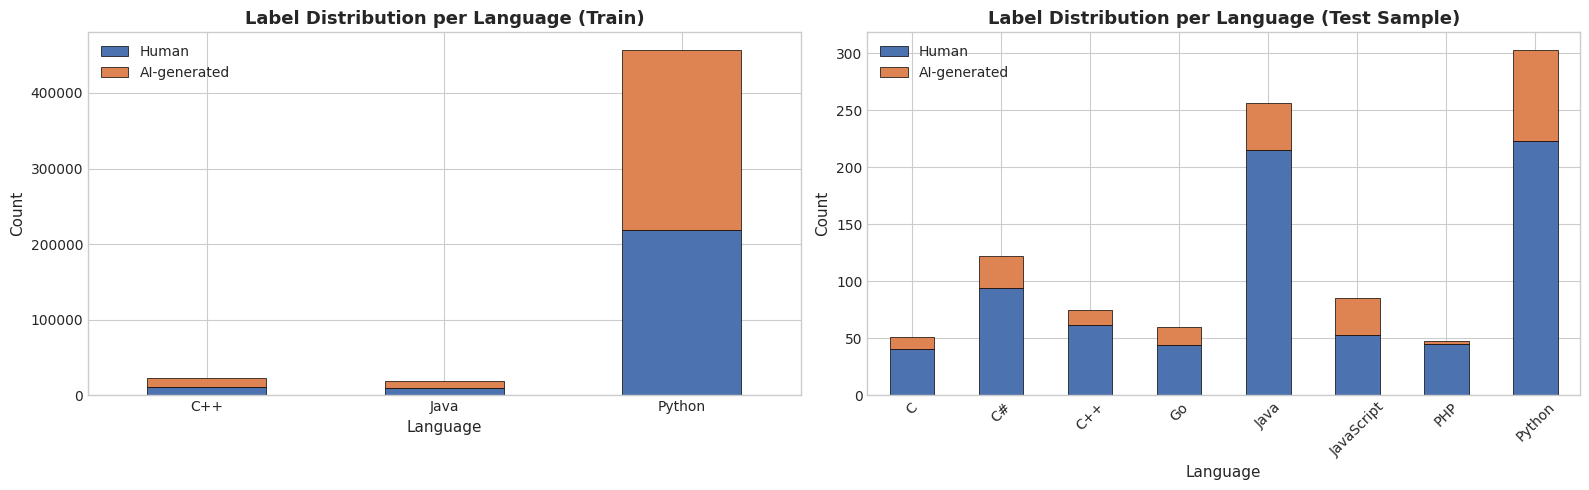

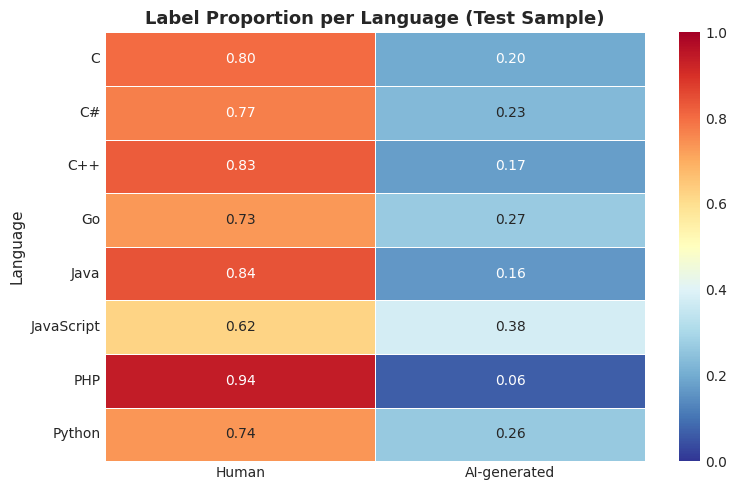

In [8]:
# Language x Label distribution — train + test_sample combined view
# Use both datasets to show all languages
combined = pd.concat([
    train[['language', 'label']].assign(source='Train'),
    test_sample[['language', 'label']].assign(source='Test Sample')
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar chart for train
ct_train = pd.crosstab(train['language'], train['label'])
ct_train.columns = ['Human', 'AI-generated']
ct_train.plot(kind='bar', stacked=True, ax=axes[0],
              color=[LABEL_COLORS[0], LABEL_COLORS[1]], edgecolor='black', linewidth=0.5)
axes[0].set_title('Label Distribution per Language (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Language', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=10)

# Stacked bar chart for test_sample (shows unseen languages)
ct_test = pd.crosstab(test_sample['language'], test_sample['label'])
ct_test.columns = ['Human', 'AI-generated']
ct_test.plot(kind='bar', stacked=True, ax=axes[1],
             color=[LABEL_COLORS[0], LABEL_COLORS[1]], edgecolor='black', linewidth=0.5)
axes[1].set_title('Label Distribution per Language (Test Sample)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Language', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Heatmap of proportions
ct_prop = pd.crosstab(test_sample['language'], test_sample['label'], normalize='index')
ct_prop.columns = ['Human', 'AI-generated']
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct_prop, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Label Proportion per Language (Test Sample)', fontsize=13, fontweight='bold')
ax.set_ylabel('Language', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Domain Shift Analysis (IMPORTANT)

The test set contains languages **not seen during training** (C, C#, Go, JavaScript, PHP). This is the key challenge for this competition. Models must generalize across programming languages.

=== Domain Shift Summary ===
Train languages:       ['C++', 'Java', 'Python']
Test sample languages: ['C', 'C#', 'C++', 'Go', 'Java', 'JavaScript', 'PHP', 'Python']
Shared:                ['C++', 'Java', 'Python']
Only in train:         []
Only in test:          ['C', 'C#', 'Go', 'JavaScript', 'PHP']

Unseen test languages account for 366/1000 = 36.6% of test sample


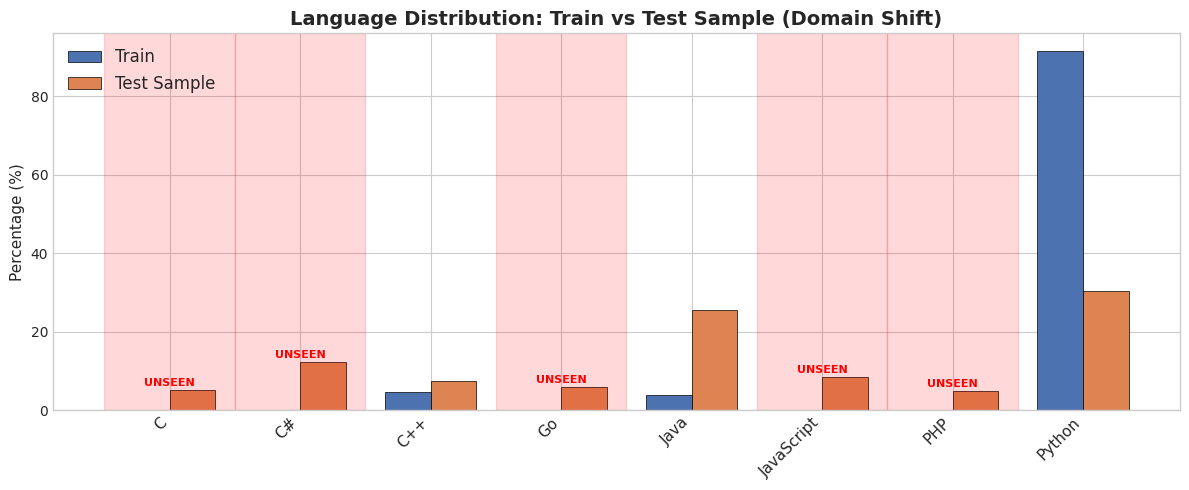

In [9]:
# Domain shift: language overlap visualization
all_train_langs = set(train['language'].unique())
all_test_langs = set(test_sample['language'].unique())
shared = all_train_langs & all_test_langs
only_train = all_train_langs - all_test_langs
only_test = all_test_langs - all_train_langs

print("=== Domain Shift Summary ===")
print(f"Train languages:       {sorted(all_train_langs)}")
print(f"Test sample languages: {sorted(all_test_langs)}")
print(f"Shared:                {sorted(shared)}")
print(f"Only in train:         {sorted(only_train)}")
print(f"Only in test:          {sorted(only_test)}")
print(f"\nUnseen test languages account for {test_sample[test_sample['language'].isin(only_test)].shape[0]}/{len(test_sample)} = "
      f"{test_sample['language'].isin(only_test).mean()*100:.1f}% of test sample")

# Side-by-side normalized language distribution
fig, ax = plt.subplots(figsize=(12, 5))
all_langs = sorted(all_train_langs | all_test_langs)

train_pcts = [(train['language'] == lang).mean() * 100 for lang in all_langs]
test_pcts = [(test_sample['language'] == lang).mean() * 100 for lang in all_langs]

x = np.arange(len(all_langs))
width = 0.35
ax.bar(x - width/2, train_pcts, width, label='Train', color='#4C72B0', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, test_pcts, width, label='Test Sample', color='#DD8452', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(all_langs, fontsize=11, rotation=45, ha='right')
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Language Distribution: Train vs Test Sample (Domain Shift)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

# Highlight unseen languages
for i, lang in enumerate(all_langs):
    if lang in only_test:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='red')
        ax.text(i, max(test_pcts[i], train_pcts[i]) + 1, 'UNSEEN',
                ha='center', fontsize=8, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

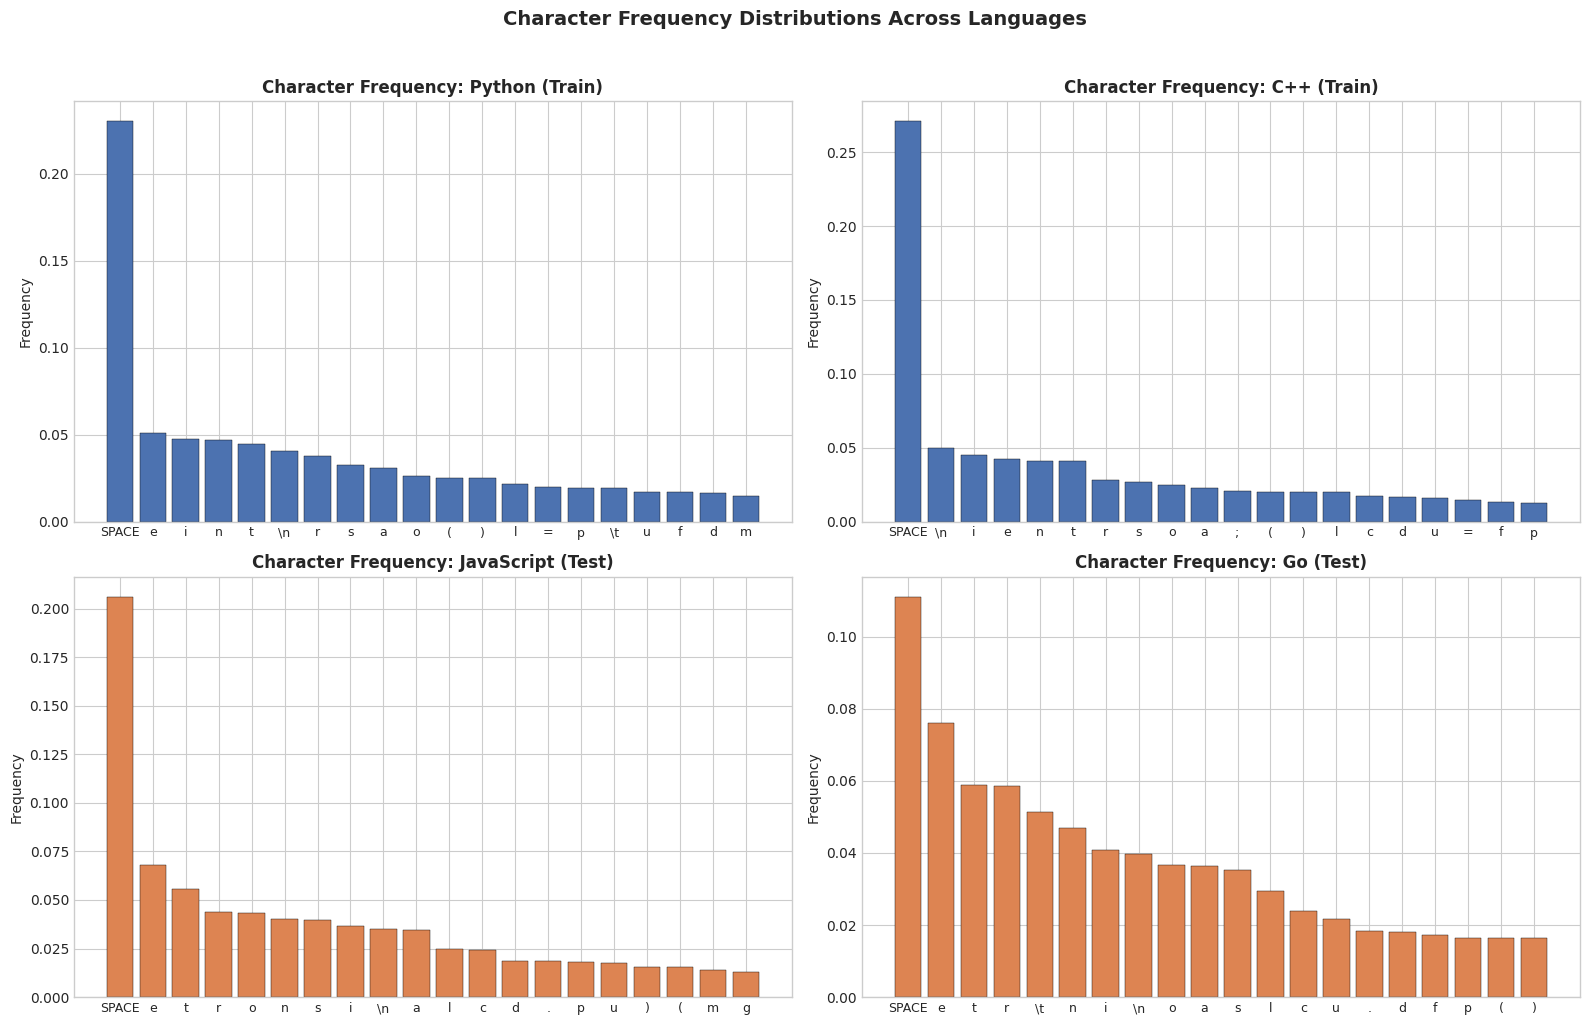

In [10]:
# Character-level analysis: compare character frequency distributions between languages
# This helps understand if language-agnostic features exist

def char_freq(code_series, top_n=30):
    """Get character frequency distribution from code."""
    all_chars = ''.join(code_series.sample(min(5000, len(code_series)), random_state=42))
    counter = Counter(all_chars)
    total = sum(counter.values())
    return {ch: count/total for ch, count in counter.most_common(top_n)}

# Compare char frequencies across languages
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sample from train and test_sample
datasets = {
    'Python (Train)': train[train['language'] == 'Python']['code'],
    'C++ (Train)': train[train['language'] == 'C++']['code'],
}
# Add test_sample languages if they exist
for lang in ['JavaScript', 'Go']:
    subset = test_sample[test_sample['language'] == lang]['code']
    if len(subset) > 0:
        datasets[f'{lang} (Test)'] = subset

for idx, (name, code_series) in enumerate(datasets.items()):
    if idx >= 4:
        break
    ax = axes[idx // 2][idx % 2]
    freq = char_freq(code_series, top_n=20)
    # Replace whitespace chars with readable names
    labels = []
    for ch in freq.keys():
        if ch == ' ':
            labels.append('SPACE')
        elif ch == '\n':
            labels.append('\\n')
        elif ch == '\t':
            labels.append('\\t')
        else:
            labels.append(ch)
    ax.bar(range(len(freq)), list(freq.values()), color='#4C72B0' if 'Train' in name else '#DD8452',
           edgecolor='black', linewidth=0.3)
    ax.set_xticks(range(len(freq)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f'Character Frequency: {name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10)

plt.suptitle('Character Frequency Distributions Across Languages', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Code Length by Language

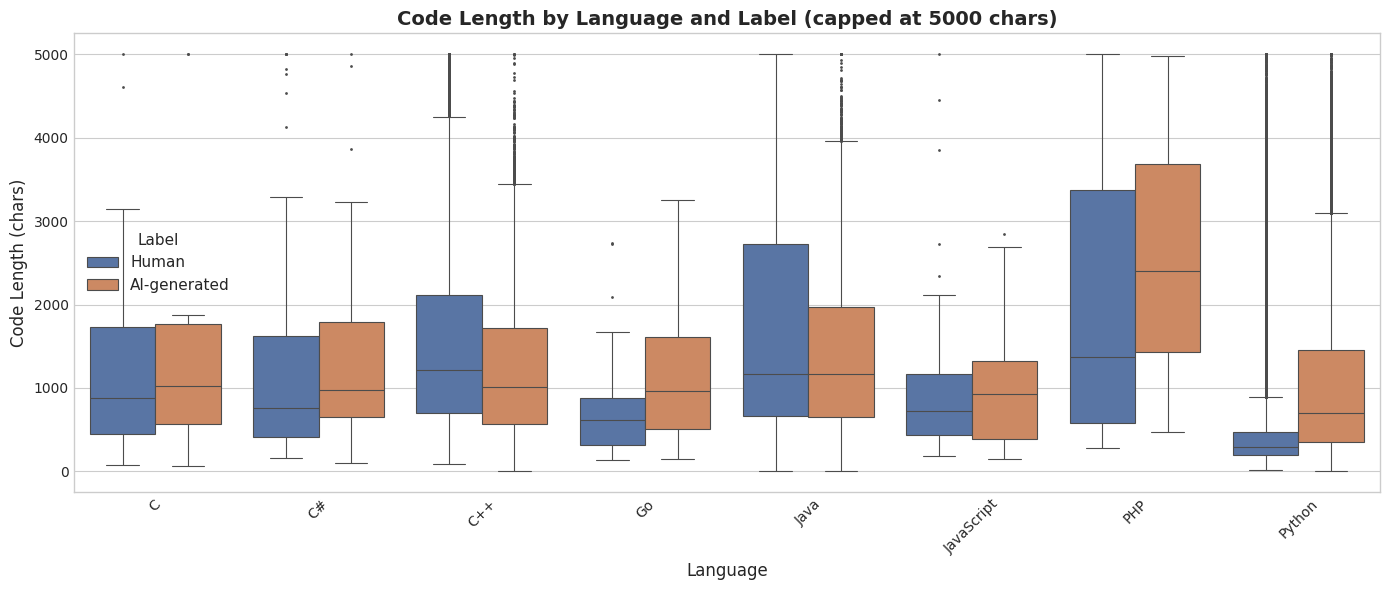

=== Median Code Length by Language and Label ===


label_name,AI-generated,Human
language,,
C,1028.0,883.0
C#,978.0,764.0
C++,1014.0,1212.0
Go,968.0,614.0
Java,1168.0,1173.0
JavaScript,925.0,721.0
PHP,2398.0,1374.0
Python,695.0,297.0


In [11]:
# Code length by language, colored by label
# Combine train and test_sample for all languages
combined_with_len = pd.concat([
    train[['code', 'language', 'label']],
    test_sample[['code', 'language', 'label']]
]).copy()
combined_with_len['code_len'] = combined_with_len['code'].str.len().clip(upper=5000)
combined_with_len['label_name'] = combined_with_len['label'].map(LABEL_NAMES)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=combined_with_len,
    x='language', y='code_len', hue='label_name',
    palette={'Human': LABEL_COLORS[0], 'AI-generated': LABEL_COLORS[1]},
    ax=ax, fliersize=1, linewidth=0.8,
    order=sorted(combined_with_len['language'].unique())
)
ax.set_title('Code Length by Language and Label (capped at 5000 chars)', fontsize=14, fontweight='bold')
ax.set_xlabel('Language', fontsize=12)
ax.set_ylabel('Code Length (chars)', fontsize=12)
ax.legend(title='Label', fontsize=11, title_fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Print median code length per language per label
print("=== Median Code Length by Language and Label ===")
summary = combined_with_len.groupby(['language', 'label_name'])['code_len'].median().unstack()
display(summary.round(0))

## 10. Quick Feature Correlations

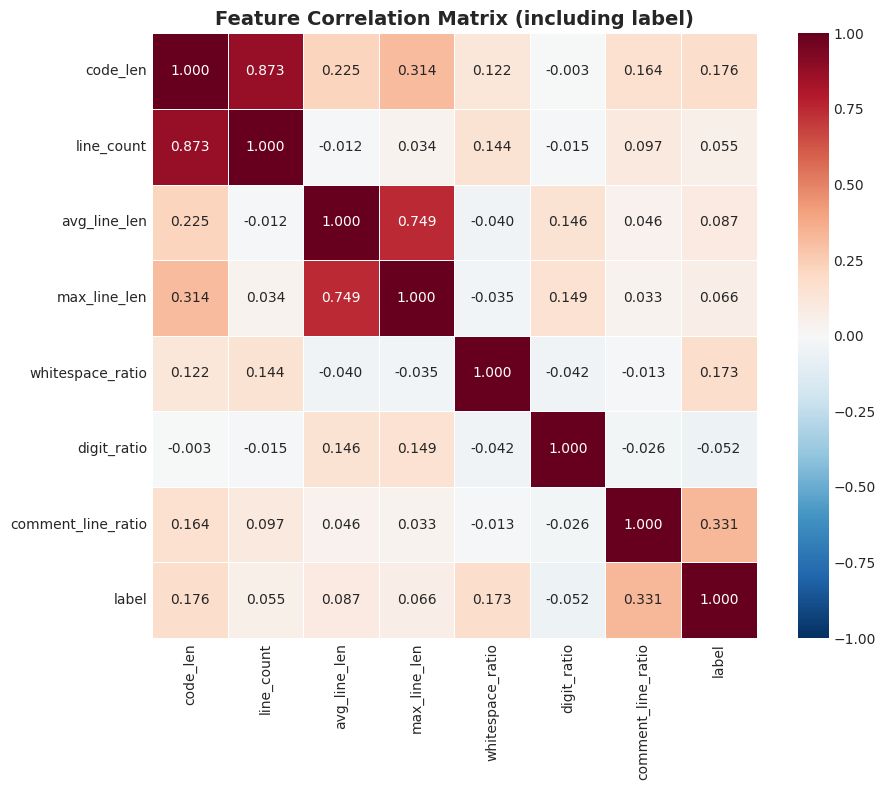

=== Correlation with Label ===
comment_line_ratio    0.330965
code_len              0.176196
whitespace_ratio      0.172783
avg_line_len          0.087038
max_line_len          0.065741
line_count            0.055467
digit_ratio          -0.052354

Positive = feature higher for AI-generated code
Negative = feature higher for human code


In [12]:
# Feature engineering on a sample for correlation analysis
feat_sample = train.sample(n=50000, random_state=42).copy()

# Compute features
feat_sample['code_len'] = feat_sample['code'].str.len()
feat_sample['line_count'] = feat_sample['code'].str.count('\n') + 1
feat_sample['avg_line_len'] = feat_sample['code_len'] / feat_sample['line_count']
feat_sample['max_line_len'] = feat_sample['code'].apply(lambda x: max(len(l) for l in x.split('\n')) if x else 0)
feat_sample['whitespace_ratio'] = feat_sample['code'].apply(lambda x: sum(c in ' \t\n' for c in x) / max(len(x), 1))
feat_sample['digit_ratio'] = feat_sample['code'].apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1))
feat_sample['comment_line_ratio'] = feat_sample['code'].apply(
    lambda x: sum(1 for l in x.split('\n') if l.strip().startswith('#') or l.strip().startswith('//')) / max(len(x.split('\n')), 1)
)

# Select feature columns
feature_cols = ['code_len', 'line_count', 'avg_line_len', 'max_line_len',
                'whitespace_ratio', 'digit_ratio', 'comment_line_ratio', 'label']

# Correlation heatmap
corr = feat_sample[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr, dtype=bool)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (including label)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with label specifically
print("=== Correlation with Label ===")
label_corr = corr['label'].drop('label').sort_values(ascending=False)
print(label_corr.to_string())
print("\nPositive = feature higher for AI-generated code")
print("Negative = feature higher for human code")

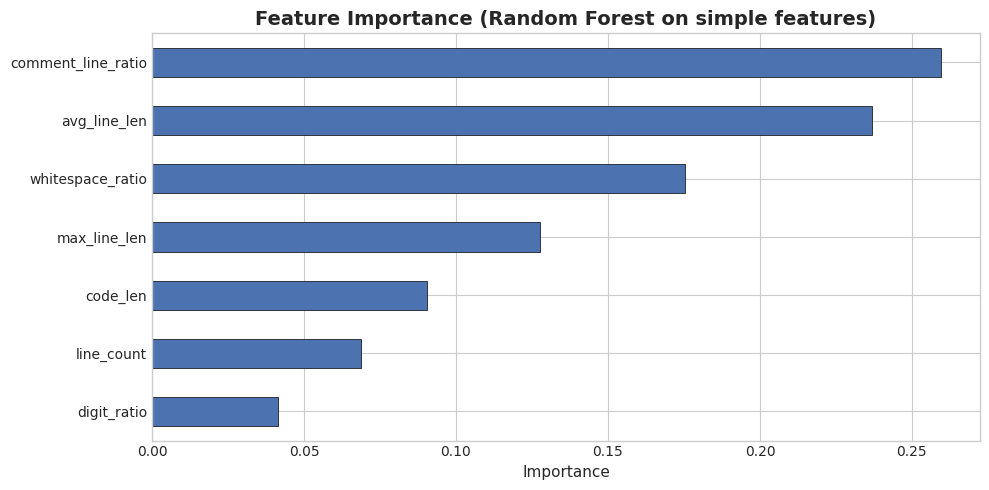

5-fold CV F1 with simple features: 0.8558 (+/- 0.0038)

Note: This is just a baseline with hand-crafted features on the training distribution.
Real performance on unseen languages will likely be much lower.


In [13]:
# Feature importance preview using a simple model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

feature_cols_no_label = [c for c in feature_cols if c != 'label']
X = feat_sample[feature_cols_no_label].fillna(0)
y = feat_sample['label']

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance bar chart
importances = pd.Series(rf.feature_importances_, index=feature_cols_no_label).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='barh', color='#4C72B0', edgecolor='black', linewidth=0.5, ax=ax)
ax.set_title('Feature Importance (Random Forest on simple features)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
plt.tight_layout()
plt.show()

# Quick accuracy on training sample
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=5, scoring='f1')
print(f"5-fold CV F1 with simple features: {scores.mean():.4f} (+/- {scores.std():.4f})")
print("\nNote: This is just a baseline with hand-crafted features on the training distribution.")
print("Real performance on unseen languages will likely be much lower.")